In [1]:
import io
import json
import os
import random
import sys
import time
import unicodedata
from collections import Counter, defaultdict

import numpy as np
import requests

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_DIR = "data"
MODEL_DIR = "models"
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print("python :", sys.version.split()[0])
print("numpy  :", np.__version__)

python : 3.11.9
numpy  : 2.4.6


In [2]:
# ----------------------------- experiment configuration -----------------------------
CONFIG = {
    # ---- pretrained fastText wiki vectors ------------------------------------------
    "vector_url": "https://dl.fbaipublicfiles.com/fasttext/vectors-wiki/wiki.%s.vec",
    # words are stored in descending corpus frequency, so reading a prefix of the file
    # keeps the most frequent words of every language. wiki.en.vec alone is 6.6 GB.
    "max_vector_lines": 200000,

    # ---- sequence models ------------------------------------------------------------
    "max_len": 40,              # tokens kept per sentence by the LSTM / GRU
    "hidden_size": 128,         # recurrent state size

    # ---- shared optimiser (Adam, mini-batch, early stopping on val macro-F1) --------
    "lr": 3e-3,
    "epochs": 60,
    "batch_size": 128,
    "l2": 1e-6,
    "patience": 8,

    # ---- multi-layer perceptron -----------------------------------------------------
    "mlp_hidden": 256,          # units per hidden layer, for n = 1 and n = 2
    "mlp_dropout": 0.2,

    # ---- recurrent models -----------------------------------------------------------
    "rnn_epochs": 30,
    "rnn_lr": 3e-3,
    "rnn_batch_size": 128,
    "rnn_patience": 5,

    # ---- fastText supervised classifier ---------------------------------------------
    "ft_epochs": 25,
    "ft_lr": 0.5,
    "ft_dim": 100,
    "ft_word_ngrams": 2,
    "ft_char_ngrams": (2, 5),
    "ft_thread": 1,             # fastText is only reproducible on a single thread
}
CONFIG

{'vector_url': 'https://dl.fbaipublicfiles.com/fasttext/vectors-wiki/wiki.%s.vec',
 'max_vector_lines': 200000,
 'max_len': 40,
 'hidden_size': 128,
 'lr': 0.003,
 'epochs': 60,
 'batch_size': 128,
 'l2': 1e-06,
 'patience': 8,
 'mlp_hidden': 256,
 'mlp_dropout': 0.2,
 'rnn_epochs': 30,
 'rnn_lr': 0.003,
 'rnn_batch_size': 128,
 'rnn_patience': 5,
 'ft_epochs': 25,
 'ft_lr': 0.5,
 'ft_dim': 100,
 'ft_word_ngrams': 2,
 'ft_char_ngrams': (2, 5),
 'ft_thread': 1}

In [3]:
# The dataset is the one built in Assignment 1: 1000 sentence-tokenized sentences for each
# language of IndicCorp v2, split 80:10:10 by stratified sampling.  We reuse the *exact*
# splits saved there so the numbers below are comparable with the TF-IDF baseline.
SEARCH_DIRS = [os.path.join("..", "Assignment - 1", "data"), DATA_DIR]


def find_a1_data(dirs=SEARCH_DIRS):
    for d in dirs:
        if all(os.path.exists(os.path.join(d, n)) for n in ("train.tsv", "val.tsv", "test.tsv")):
            return d
    raise FileNotFoundError("Assignment 1 splits not found - run Assignment 1 first")


def read_split(directory, name):
    labels, texts = [], []
    with io.open(os.path.join(directory, name + ".tsv"), encoding="utf-8") as f:
        next(f)                                  # header: label \t text
        for line in f:
            lab, _, txt = line.rstrip("\n").partition("\t")
            labels.append(lab)
            texts.append(txt)
    return texts, labels


A1_DIR = find_a1_data()
X_train_txt, y_train_lab = read_split(A1_DIR, "train")
X_val_txt, y_val_lab = read_split(A1_DIR, "val")
X_test_txt, y_test_lab = read_split(A1_DIR, "test")

LABELS = sorted(set(y_train_lab))
LABEL2ID = {lab: i for i, lab in enumerate(LABELS)}
N_CLASSES = len(LABELS)

y_train = np.array([LABEL2ID[l] for l in y_train_lab], dtype=np.int32)
y_val = np.array([LABEL2ID[l] for l in y_val_lab], dtype=np.int32)
y_test = np.array([LABEL2ID[l] for l in y_test_lab], dtype=np.int32)

print("splits loaded from", A1_DIR)
print("train %6d   val %5d   test %5d" % (len(X_train_txt), len(X_val_txt), len(X_test_txt)))
print("%d languages:" % N_CLASSES, " ".join(LABELS))
print("per language ->  train %d | val %d | test %d" % (
    Counter(y_train_lab).most_common(1)[0][1],
    Counter(y_val_lab).most_common(1)[0][1],
    Counter(y_test_lab).most_common(1)[0][1]))

splits loaded from ..\Assignment - 1\data
train  18400   val  2300   test  2300
23 languages: as bd bn dg en gom gu kha kn ks mai ml mni mr ne or pa sa sat sd ta te ur
per language ->  train 800 | val 100 | test 100


In [4]:
# The same Unicode-aware tokenizer as Assignment 1.  `\w+` is unusable here: Indic vowel
# signs are combining marks (Unicode category Mn / Mc), and str.isalnum() reports those as
# False - so a `\w+` tokenizer would tear every Devanagari word apart at its matras.
_MARK_CATEGORIES = {"Mn", "Mc", "Me"}
_CHAR_CLASS_CACHE = {}


def is_word_char(ch):
    cached = _CHAR_CLASS_CACHE.get(ch)
    if cached is None:
        cached = ch.isalnum() or unicodedata.category(ch) in _MARK_CATEGORIES
        _CHAR_CLASS_CACHE[ch] = cached
    return cached


def word_tokenize(text):
    tokens, buf = [], []
    for ch in text:
        if is_word_char(ch):
            buf.append(ch)
        elif buf:
            tokens.append("".join(buf))
            buf = []
    if buf:
        tokens.append("".join(buf))
    return tokens


TOK_TRAIN = [word_tokenize(t.lower()) for t in X_train_txt]
TOK_VAL = [word_tokenize(t.lower()) for t in X_val_txt]
TOK_TEST = [word_tokenize(t.lower()) for t in X_test_txt]

# every word type in the dataset - the only words we need vectors for
CORPUS_VOCAB = set()
for toks in TOK_TRAIN + TOK_VAL + TOK_TEST:
    CORPUS_VOCAB.update(toks)

lengths = np.array([len(t) for t in TOK_TRAIN])
print("word types in the dataset : {:,}".format(len(CORPUS_VOCAB)))
print("sentence length (tokens)  : mean %.1f  median %d  p95 %d  max %d" % (
    lengths.mean(), np.median(lengths), np.percentile(lengths, 95), lengths.max()))
print("example:", TOK_TRAIN[0][:8])

word types in the dataset : 120,336
sentence length (tokens)  : mean 15.2  median 12  p95 36  max 66
example: ['شِواجی', 'بھونٛسلے', 'یا', 'چھَترَپٔتی', 'شِواجی', 'مَہارازٕ', 'اوس', 'اَکھ']


In [5]:
# --------------------------- pretrained fastText wiki vectors ---------------------------
# fastText publishes one 300-dimensional model per Wikipedia language.  The files are text
# and enormous (wiki.en.vec is 6.6 GB), but we only ever need the ~120k word types that
# actually occur in our dataset, and words are stored in descending corpus frequency.  So we
# *stream* each file, keep the vectors of words we need, and stop after `max_vector_lines`.
VEC_DIR = os.path.join(DATA_DIR, "wiki_vectors")
os.makedirs(VEC_DIR, exist_ok=True)


def fetch_language_vectors(lang, vocab, cfg=CONFIG):
    """Download the wiki vectors of one language, keeping only words in `vocab`.

    Returns (words, ranks, matrix, lines_scanned, available).  `ranks` is the position of the
    word in the fastText file, i.e. its frequency rank in that language's Wikipedia.
    """
    import urllib.error
    import urllib.request

    words, ranks, vecs = [], [], []
    url = cfg["vector_url"] % lang
    try:
        resp = urllib.request.urlopen(urllib.request.Request(url), timeout=120)
    except urllib.error.HTTPError as err:
        if err.code in (403, 404):        # fastText has no model for this language
            return [], [], np.zeros((0, 300), dtype=np.float32), 0, False
        raise

    with resp:
        reader = io.TextIOWrapper(io.BufferedReader(resp, 1 << 20),
                                  encoding="utf-8", errors="ignore")
        dim = int(reader.readline().split()[1])
        n = 0
        for line in reader:
            if n >= cfg["max_vector_lines"]:
                break
            parts = line.rstrip().split(" ")
            if len(parts) == dim + 1 and parts[0] in vocab:
                words.append(parts[0])
                ranks.append(n)
                vecs.append(np.asarray(parts[1:], dtype=np.float32))
            n += 1
    matrix = np.vstack(vecs) if vecs else np.zeros((0, dim), dtype=np.float32)
    return words, ranks, matrix, n, True


def load_language_vectors(lang, vocab, cfg=CONFIG):
    """Cached wrapper around `fetch_language_vectors` (the download is the slow part)."""
    meta_path = os.path.join(VEC_DIR, lang + ".json")
    npy_path = os.path.join(VEC_DIR, lang + ".npy")
    if os.path.exists(meta_path) and os.path.exists(npy_path):
        with io.open(meta_path, encoding="utf-8") as f:
            meta = json.load(f)
        return meta, np.load(npy_path)

    words, ranks, matrix, scanned, available = fetch_language_vectors(lang, vocab, cfg)
    meta = {"words": words, "ranks": ranks, "scanned": scanned, "available": available}
    np.save(npy_path, matrix)
    with io.open(meta_path, "w", encoding="utf-8") as f:
        json.dump(meta, f, ensure_ascii=False)
    return meta, matrix


t0 = time.time()
from concurrent.futures import ThreadPoolExecutor

with ThreadPoolExecutor(max_workers=4) as pool:
    fetched = list(pool.map(lambda l: load_language_vectors(l, CORPUS_VOCAB), LABELS))

LANG_VECTORS = dict(zip(LABELS, fetched))
print("fastText wiki vectors ready in %.0fs\n" % (time.time() - t0))
print("%-6s %10s %10s   %s" % ("lang", "scanned", "kept", "model"))
for lang in LABELS:
    meta, matrix = LANG_VECTORS[lang]
    print("%-6s %10s %10d   %s" % (
        lang,
        "{:,}".format(meta["scanned"]) if meta["available"] else "-",
        matrix.shape[0],
        "wiki.%s.vec" % lang if meta["available"] else "NOT PUBLISHED by fastText"))

fastText wiki vectors ready in 4s

lang      scanned       kept   model
as         47,214      10081   wiki.as.vec
bd              -          0   NOT PUBLISHED by fastText
bn        145,350      11597   wiki.bn.vec
dg              -          0   NOT PUBLISHED by fastText
en        200,000       8763   wiki.en.vec
gom        36,404       6482   wiki.gom.vec
gu         74,632       9029   wiki.gu.vec
kha             -          0   NOT PUBLISHED by fastText
kn        188,248      10952   wiki.kn.vec
ks          1,489        904   wiki.ks.vec
mai        12,366       5284   wiki.mai.vec
ml        189,674      10043   wiki.ml.vec
mni             -          0   NOT PUBLISHED by fastText
mr         93,882      14885   wiki.mr.vec
ne         67,810      12747   wiki.ne.vec
or         42,165       6011   wiki.or.vec
pa         56,850       8750   wiki.pa.vec
sa         48,899       7383   wiki.sa.vec
sat             -          0   NOT PUBLISHED by fastText
sd         23,618       7383   wiki.sd.

In [6]:
# --------------------------- one merged embedding table ---------------------------------
# Each fastText model lives in its *own* vector space, so the 18 models cannot simply be
# concatenated.  For language identification that does not matter: what the classifier needs
# is a lookup that is (a) defined for the words of every language and (b) different for
# words of different languages - which is exactly what merging the per-language tables gives.
# A word that appears in several models (shared scripts, loan words, digits, Latin strings)
# is resolved to the model in which it is *most frequent*, i.e. the smallest frequency rank.
EMB_DIM = int(max(m.shape[1] for _, m in LANG_VECTORS.values()))

best = {}                                   # word -> (rank, source language, row index)
for lang in LABELS:
    meta, matrix = LANG_VECTORS[lang]
    for row, (word, rank) in enumerate(zip(meta["words"], meta["ranks"])):
        prev = best.get(word)
        if prev is None or rank < prev[0]:
            best[word] = (rank, lang, row)

# index 0 is the padding slot and index 1 the unknown-word slot; both are the zero vector,
# so an unknown token contributes nothing to a sentence average.
PAD_ID, UNK_ID = 0, 1
VOCAB = ["<pad>", "<unk>"] + sorted(best)
WORD2ID = {w: i for i, w in enumerate(VOCAB)}

EMB = np.zeros((len(VOCAB), EMB_DIM), dtype=np.float32)
for word, (_, lang, row) in best.items():
    EMB[WORD2ID[word]] = LANG_VECTORS[lang][1][row]

# unit-normalise every word vector: fastText norms encode corpus frequency, which would
# otherwise let frequent words dominate a sentence average for no linguistic reason.
norms = np.linalg.norm(EMB, axis=1, keepdims=True)
np.divide(EMB, norms, out=EMB, where=norms > 0)

EMB_SOURCE = {w: lang for w, (_, lang, _) in best.items()}
print("embedding table: {:,} words x {}d".format(len(VOCAB), EMB_DIM))
print("words claimed by more than one model are resolved to their most frequent source.")
print("\nwords contributed per source model:")
by_src = Counter(EMB_SOURCE.values())
for lang in LABELS:
    print("  %-6s %7d" % (lang, by_src.get(lang, 0)))

embedding table: 69,797 words x 300d
words claimed by more than one model are resolved to their most frequent source.

words contributed per source model:
  as        3865
  bd           0
  bn        4302
  dg           0
  en        6701
  gom       1451
  gu        4600
  kha          0
  kn        5272
  ks         462
  mai       1391
  ml        3790
  mni          0
  mr        6731
  ne        5355
  or        1635
  pa        3974
  sa        1534
  sat          0
  sd        3874
  ta        5298
  te        4502
  ur        5058


In [7]:
# ------------------------------ embedding coverage, per language ------------------------
def coverage(tok_docs, labs):
    per_lang = defaultdict(lambda: [0, 0, 0, 0])   # tokens, hits, sentences, empty sentences
    for toks, lab in zip(tok_docs, labs):
        hits = sum(1 for w in toks if w in WORD2ID)
        rec = per_lang[lab]
        rec[0] += len(toks)
        rec[1] += hits
        rec[2] += 1
        rec[3] += (hits == 0)
    return per_lang


cov = coverage(TOK_TRAIN + TOK_VAL + TOK_TEST, list(y_train_lab) + list(y_val_lab) + list(y_test_lab))
print("%-6s %10s %10s %9s %12s   %s" % ("lang", "tokens", "in-vocab", "coverage",
                                        "empty sents", "own wiki model"))
COVERAGE = {}
for lang in LABELS:
    tokens, hits, sents, empty = cov[lang]
    COVERAGE[lang] = hits / tokens if tokens else 0.0
    print("%-6s %10d %10d %8.1f%% %8d/%-4d   %s" % (
        lang, tokens, hits, 100 * COVERAGE[lang], empty, sents,
        "yes" if LANG_VECTORS[lang][0]["available"] else "NO"))

overall = sum(cov[l][1] for l in LABELS) / sum(cov[l][0] for l in LABELS)
print("\noverall token coverage: %.1f%%" % (100 * overall))
print("languages without a published wiki model:",
      ", ".join(l for l in LABELS if not LANG_VECTORS[l][0]["available"]))

lang       tokens   in-vocab  coverage  empty sents   own wiki model
as          15856      12717     80.2%        0/1000   yes
bd          17116       5825     34.0%      110/1000   NO
bn          12460      10267     82.4%        0/1000   yes
dg          13615       7818     57.4%       17/1000   NO
en          19734      18814     95.3%        0/1000   yes
gom         11439       9587     83.8%        0/1000   yes
gu          15071      13042     86.5%        0/1000   yes
kha         23804      21297     89.5%        0/1000   NO
kn          11614       9704     83.6%        1/1000   yes
ks          12470       4245     34.0%       33/1000   yes
mai         12518       9363     74.8%        6/1000   yes
ml          10165       6503     64.0%        1/1000   yes
mni         17476        635      3.6%      881/1000   NO
mr          12181      10365     85.1%        0/1000   yes
ne          14153      12226     86.4%        0/1000   yes
or          16017      11400     71.2%        5/10

In [8]:
# --------------------------- evaluation metrics, from scratch ---------------------------
# The assignment forbids sklearn, so precision / recall / F1 / macro-F1 are implemented here.
def confusion_matrix(y_true, y_pred, n_classes):
    cm = np.zeros((n_classes, n_classes), dtype=np.int64)
    np.add.at(cm, (np.asarray(y_true), np.asarray(y_pred)), 1)
    return cm


def prf_per_class(y_true, y_pred, n_classes):
    cm = confusion_matrix(y_true, y_pred, n_classes)
    tp = np.diag(cm).astype(np.float64)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp
    precision = np.divide(tp, tp + fp, out=np.zeros_like(tp), where=(tp + fp) > 0)
    recall = np.divide(tp, tp + fn, out=np.zeros_like(tp), where=(tp + fn) > 0)
    denom = precision + recall
    f1 = np.divide(2 * precision * recall, denom, out=np.zeros_like(tp), where=denom > 0)
    return precision, recall, f1, cm.sum(axis=1)


def macro_f1(y_true, y_pred, n_classes=None):
    n_classes = n_classes if n_classes is not None else N_CLASSES
    return float(prf_per_class(y_true, y_pred, n_classes)[2].mean())


def accuracy(y_true, y_pred):
    return float((np.asarray(y_true) == np.asarray(y_pred)).mean())


def classification_report(y_true, y_pred, labels=None):
    labels = labels if labels is not None else LABELS
    p, r, f, support = prf_per_class(y_true, y_pred, len(labels))
    width = max(len(l) for l in labels) + 2
    lines = ["%-*s%8s%8s%8s%9s" % (width, "language", "prec", "recall", "f1", "support"),
             "-" * (width + 33)]
    for i, lab in enumerate(labels):
        lines.append("%-*s%8.4f%8.4f%8.4f%9d" % (width, lab, p[i], r[i], f[i], support[i]))
    lines.append("-" * (width + 33))
    lines.append("%-*s%8.4f%8.4f%8.4f%9d" % (width, "macro avg", p.mean(), r.mean(), f.mean(),
                                             support.sum()))
    lines.append("%-*s%8.4f" % (width, "accuracy", accuracy(y_true, y_pred)))
    return "\n".join(lines)


# sanity check on a tiny hand-computable example
_yt = np.array([0, 0, 1, 1, 2])
_yp = np.array([0, 1, 1, 1, 2])
# class0: P=1/1, R=1/2, F1=0.6667 | class1: P=2/3, R=1, F1=0.8 | class2: P=R=F1=1
print("macro-F1 (expected 0.8222):", round(macro_f1(_yt, _yp, 3), 4))

macro-F1 (expected 0.8222): 0.8222


In [9]:
# ------------------- feature set 1: the average of a sentence's word vectors -------------
def average_vectors(tok_docs, emb=None, word2id=None):
    """Mean of the (unit-norm) fastText vectors of the in-vocabulary words of a sentence."""
    emb = EMB if emb is None else emb
    word2id = WORD2ID if word2id is None else word2id
    X = np.zeros((len(tok_docs), emb.shape[1]), dtype=np.float32)
    for i, toks in enumerate(tok_docs):
        rows = [word2id[w] for w in toks if w in word2id]
        if rows:
            X[i] = emb[rows].mean(axis=0)
    return X


RAW_A_train = average_vectors(TOK_TRAIN)
RAW_A_val = average_vectors(TOK_VAL)
RAW_A_test = average_vectors(TOK_TEST)

# standardise with training-set statistics - gradient descent on raw averaged vectors is
# badly conditioned because the 300 dimensions have very different means and scales.
MU = RAW_A_train.mean(axis=0)
SD = RAW_A_train.std(axis=0)
SD[SD == 0] = 1.0
A_train = (RAW_A_train - MU) / SD
A_val = (RAW_A_val - MU) / SD
A_test = (RAW_A_test - MU) / SD

print("averaged-vector features:", A_train.shape, A_val.shape, A_test.shape)
print("sentences with no in-vocabulary word at all:  train %d   val %d   test %d" % (
    int((np.abs(RAW_A_train).max(axis=1) == 0).sum()),
    int((np.abs(RAW_A_val).max(axis=1) == 0).sum()),
    int((np.abs(RAW_A_test).max(axis=1) == 0).sum())))

averaged-vector features: (18400, 300) (2300, 300) (2300, 300)
sentences with no in-vocabulary word at all:  train 1629   val 206   test 210


In [10]:
# ------------------------------- optimiser and dense models -----------------------------
class Adam:
    """Adam over a fixed list of parameter arrays, updated in place."""

    def __init__(self, params, lr, beta1=0.9, beta2=0.999, eps=1e-8):
        self.params = params
        self.lr, self.beta1, self.beta2, self.eps = lr, beta1, beta2, eps
        self.m = [np.zeros_like(p) for p in params]
        self.v = [np.zeros_like(p) for p in params]
        self.t = 0

    def step(self, grads, clip=None):
        if clip is not None:                       # global gradient-norm clipping
            total = np.sqrt(sum(float((g * g).sum()) for g in grads))
            if total > clip:
                scale = clip / (total + 1e-12)
                grads = [g * scale for g in grads]
        self.t += 1
        bc1 = 1.0 - self.beta1 ** self.t
        bc2 = 1.0 - self.beta2 ** self.t
        for p, g, m, v in zip(self.params, grads, self.m, self.v):
            m *= self.beta1
            m += (1 - self.beta1) * g
            v *= self.beta2
            v += (1 - self.beta2) * (g * g)
            p -= self.lr * (m / bc1) / (np.sqrt(v / bc2) + self.eps)


def softmax(scores):
    scores = scores - scores.max(axis=1, keepdims=True)      # numerical stability
    np.exp(scores, out=scores)
    scores /= scores.sum(axis=1, keepdims=True)
    return scores


def cross_entropy(P, y):
    return float(-np.log(np.clip(P[np.arange(len(y)), y], 1e-12, None)).mean())


class MLP:
    """Feed-forward softmax classifier with `len(hidden)` ReLU hidden layers.

    hidden = ()      -> multinomial logistic regression (n = 0 hidden layers)
    hidden = (h,)    -> one hidden layer                (n = 1)
    hidden = (h, h)  -> two hidden layers               (n = 2)
    """

    def __init__(self, n_features, n_classes, hidden=(), lr=CONFIG["lr"], l2=CONFIG["l2"],
                 dropout=0.0, seed=SEED):
        self.sizes = [n_features] + list(hidden) + [n_classes]
        self.n_hidden = len(hidden)
        self.lr, self.l2, self.dropout = lr, l2, dropout
        rng = np.random.RandomState(seed)
        self.W, self.b = [], []
        for i in range(len(self.sizes) - 1):
            fan_in, fan_out = self.sizes[i], self.sizes[i + 1]
            # He initialisation for the ReLU layers, Xavier for the linear output layer
            scale = np.sqrt(2.0 / fan_in) if i < len(self.sizes) - 2 else np.sqrt(1.0 / fan_in)
            self.W.append((rng.randn(fan_in, fan_out) * scale).astype(np.float32))
            self.b.append(np.zeros(fan_out, dtype=np.float32))
        self.rng = rng
        self.history_ = []

    # ---------------------------------------------------------------- forward / backward
    def _forward(self, X, train=False):
        acts, masks = [X], []
        h = X
        for i in range(len(self.W) - 1):
            h = np.maximum(h @ self.W[i] + self.b[i], 0.0)          # ReLU
            if train and self.dropout > 0:
                mask = (self.rng.rand(*h.shape) >= self.dropout).astype(np.float32)
                h = h * mask / (1.0 - self.dropout)                 # inverted dropout
                masks.append(mask)
            else:
                masks.append(None)
            acts.append(h)
        logits = h @ self.W[-1] + self.b[-1]
        return logits, acts, masks

    def _backward(self, acts, masks, dlogits):
        gW = [None] * len(self.W)
        gb = [None] * len(self.b)
        delta = dlogits
        for i in range(len(self.W) - 1, -1, -1):
            gW[i] = acts[i].T @ delta + self.l2 * self.W[i]
            gb[i] = delta.sum(axis=0)
            if i > 0:
                delta = delta @ self.W[i].T
                if masks[i - 1] is not None:
                    delta = delta * masks[i - 1] / (1.0 - self.dropout)
                delta = delta * (acts[i] > 0)                       # ReLU derivative
        return gW + gb

    # ---------------------------------------------------------------- inference
    def predict_proba(self, X, batch=4096):
        out = np.empty((X.shape[0], self.sizes[-1]), dtype=np.float64)
        for s in range(0, X.shape[0], batch):
            logits, _, _ = self._forward(X[s:s + batch])
            out[s:s + batch] = softmax(logits.astype(np.float64))
        return out

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

    # ---------------------------------------------------------------- training
    def fit(self, X, y, X_val, y_val, epochs=CONFIG["epochs"], batch_size=CONFIG["batch_size"],
            patience=CONFIG["patience"], verbose=True):
        opt = Adam(self.W + self.b, self.lr)
        n = X.shape[0]
        best_score, best_state, stale = -1.0, None, 0
        for epoch in range(1, epochs + 1):
            t0 = time.time()
            order = self.rng.permutation(n)
            epoch_loss = 0.0
            for start in range(0, n, batch_size):
                idx = order[start:start + batch_size]
                Xb, yb = X[idx], y[idx]
                B = len(idx)
                logits, acts, masks = self._forward(Xb, train=True)
                P = softmax(logits.astype(np.float64))
                epoch_loss += cross_entropy(P, yb) * B
                P[np.arange(B), yb] -= 1.0
                P /= B
                opt.step(self._backward(acts, masks, P.astype(np.float32)))
            pred = self.predict(X_val)
            rec = {"epoch": epoch, "loss": epoch_loss / n,
                   "val_macro_f1": macro_f1(y_val, pred), "val_acc": accuracy(y_val, pred),
                   "sec": time.time() - t0}
            self.history_.append(rec)
            if verbose and (epoch == 1 or epoch % 10 == 0):
                print("  epoch %3d  loss %.4f  val_acc %.4f  val_macroF1 %.4f  (%.1fs)" % (
                    rec["epoch"], rec["loss"], rec["val_acc"], rec["val_macro_f1"], rec["sec"]))
            if rec["val_macro_f1"] > best_score + 1e-5:
                best_score, stale = rec["val_macro_f1"], 0
                best_state = ([w.copy() for w in self.W], [b.copy() for b in self.b])
            else:
                stale += 1
                if stale >= patience:
                    if verbose:
                        print("  early stop at epoch %d (best val macro-F1 %.4f)"
                              % (epoch, best_score))
                    break
        if best_state is not None:
            self.W, self.b = best_state
        return self


def count_params(model):
    return int(sum(w.size for w in model.W) + sum(b.size for b in model.b))


# every model's test-set score is collected here and compared at the end
RESULTS = []


def evaluate(name, detail, y_pred_val, y_pred_test, n_parameters, seconds):
    row = {
        "model": name,
        "detail": detail,
        "params": int(n_parameters),
        "train_seconds": round(float(seconds), 1),
        "val_macro_f1": macro_f1(y_val, y_pred_val),
        "val_accuracy": accuracy(y_val, y_pred_val),
        "test_macro_f1": macro_f1(y_test, y_pred_test),
        "test_accuracy": accuracy(y_test, y_pred_test),
    }
    RESULTS.append(row)
    print("\n%s  ->  val macro-F1 %.4f | TEST macro-F1 %.4f | test accuracy %.4f" % (
        name, row["val_macro_f1"], row["test_macro_f1"], row["test_accuracy"]))

In [11]:
# ============================ 1. logistic regression =====================================
# Multinomial (softmax) logistic regression on the averaged fastText word vectors.
print("1. LOGISTIC REGRESSION on averaged word vectors")
t0 = time.time()
lr_model = MLP(A_train.shape[1], N_CLASSES, hidden=(), lr=CONFIG["lr"], l2=CONFIG["l2"])
lr_model.fit(A_train, y_train, A_val, y_val)
lr_secs = time.time() - t0

lr_val_pred = lr_model.predict(A_val)
lr_test_pred = lr_model.predict(A_test)
evaluate("Logistic regression", "avg. word vectors, softmax",
         lr_val_pred, lr_test_pred, count_params(lr_model), lr_secs)

1. LOGISTIC REGRESSION on averaged word vectors


  epoch   1  loss 0.5960  val_acc 0.8435  val_macroF1 0.8320  (0.4s)


  epoch  10  loss 0.2554  val_acc 0.8557  val_macroF1 0.8468  (0.4s)


  early stop at epoch 12 (best val macro-F1 0.8499)

Logistic regression  ->  val macro-F1 0.8499 | TEST macro-F1 0.8451 | test accuracy 0.8561


In [12]:
# ============================ 2. multi-layer perceptron, n = 0, 1, 2 =====================
# n = 0 has no hidden layer, so it *is* the logistic regression of section 1 - trained again
# from a different random seed it doubles as a check on run-to-run variance.
MLP_MODELS = {}
for n_hidden in (0, 1, 2):
    hidden = tuple([CONFIG["mlp_hidden"]] * n_hidden)
    print("\n2. MULTI-LAYER PERCEPTRON with n = %d hidden layer(s)  %s" % (
        n_hidden, "-> identical in form to logistic regression" if n_hidden == 0
        else "(%s units, dropout %.1f)" % (" x ".join(str(h) for h in hidden),
                                           CONFIG["mlp_dropout"])))
    t0 = time.time()
    model = MLP(A_train.shape[1], N_CLASSES, hidden=hidden, lr=CONFIG["lr"], l2=CONFIG["l2"],
                dropout=CONFIG["mlp_dropout"] if n_hidden else 0.0, seed=SEED + 1 + n_hidden)
    model.fit(A_train, y_train, A_val, y_val)
    secs = time.time() - t0
    MLP_MODELS[n_hidden] = model
    evaluate("MLP (n=%d)" % n_hidden,
             "avg. word vectors, hidden=%s" % (list(hidden),),
             model.predict(A_val), model.predict(A_test), count_params(model), secs)


2. MULTI-LAYER PERCEPTRON with n = 0 hidden layer(s)  -> identical in form to logistic regression


  epoch   1  loss 0.5893  val_acc 0.8426  val_macroF1 0.8298  (0.7s)


  epoch  10  loss 0.2573  val_acc 0.8557  val_macroF1 0.8471  (0.5s)


  epoch  20  loss 0.2379  val_acc 0.8522  val_macroF1 0.8431  (0.7s)


  early stop at epoch 21 (best val macro-F1 0.8493)

MLP (n=0)  ->  val macro-F1 0.8493 | TEST macro-F1 0.8464 | test accuracy 0.8578

2. MULTI-LAYER PERCEPTRON with n = 1 hidden layer(s)  (256 units, dropout 0.2)


...

  early stop at epoch 13 (best val macro-F1 0.8536)

MLP (n=1)  ->  val macro-F1 0.8536 | TEST macro-F1 0.8591 | test accuracy 0.8696

2. MULTI-LAYER PERCEPTRON with n = 2 hidden layer(s)  (256 x 256 units, dropout 0.2)


  epoch   1  loss 0.5321  val_acc 0.8396  val_macroF1 0.8256  (9.6s)


  epoch  10  loss 0.2247  val_acc 0.8513  val_macroF1 0.8402  (1.0s)


  epoch  20  loss 0.1872  val_acc 0.8613  val_macroF1 0.8512  (1.4s)


  early stop at epoch 25 (best val macro-F1 0.8516)

MLP (n=2)  ->  val macro-F1 0.8516 | TEST macro-F1 0.8581 | test accuracy 0.8696


In [13]:
# ---------------- feature set 2: padded token-id sequences for the LSTM / GRU ------------
# The recurrent models read the sentence word by word instead of collapsing it into a mean,
# so each sentence becomes a fixed-length array of row indices into EMB.  Index 0 is <pad>
# (masked out at every time step) and index 1 is <unk>.
MAX_LEN = CONFIG["max_len"]


def to_sequences(tok_docs, max_len=MAX_LEN):
    ids = np.zeros((len(tok_docs), max_len), dtype=np.int32)      # 0 = <pad>
    lengths = np.zeros(len(tok_docs), dtype=np.int32)
    for i, toks in enumerate(tok_docs):
        toks = toks[:max_len]
        if not toks:                                              # keep at least one step
            toks = ["<unk>"]
        for j, w in enumerate(toks):
            ids[i, j] = WORD2ID.get(w, UNK_ID)
        lengths[i] = len(toks)
    return ids, lengths


S_train, L_train = to_sequences(TOK_TRAIN)
S_val, L_val = to_sequences(TOK_VAL)
S_test, L_test = to_sequences(TOK_TEST)

print("sequence tensors:", S_train.shape, S_val.shape, S_test.shape)
print("tokens truncated by max_len=%d: %.2f%% of training sentences" % (
    MAX_LEN, 100 * np.mean([len(t) > MAX_LEN for t in TOK_TRAIN])))
print("mean usable length: %.1f tokens" % L_train.mean())

sequence tensors: (18400, 40) (2300, 40) (2300, 40)


tokens truncated by max_len=40: 2.97% of training sentences
mean usable length: 14.9 tokens


In [14]:
# --------------------- LSTM and GRU classifiers, written from scratch --------------------
def sigmoid(x):
    # 0.5 * (tanh(x/2) + 1) == 1 / (1 + exp(-x)), but without the overflow warning
    return 0.5 * (np.tanh(0.5 * x) + 1.0)


class RecurrentClassifier:
    """A single-layer LSTM or GRU over frozen fastText embeddings.

    The sentence representation is the hidden state after the last *real* token (padding is
    masked out, so a short sentence simply stops updating its state).  A linear softmax layer
    on top of it produces the language distribution.  Forward pass, BPTT and Adam are all
    implemented here; only numpy is used.

    LSTM gate order in the stacked weights: i, f, o, g.
    GRU  gate order in the stacked weights: z, r, n.
    """

    def __init__(self, embeddings, n_classes, cell="lstm", hidden_size=CONFIG["hidden_size"],
                 lr=CONFIG["rnn_lr"], l2=CONFIG["l2"], clip=5.0, seed=SEED):
        assert cell in ("lstm", "gru")
        self.emb = embeddings
        self.cell = cell
        self.H = hidden_size
        self.D = embeddings.shape[1]
        self.C = n_classes
        self.lr, self.l2, self.clip = lr, l2, clip
        self.n_gates = 4 if cell == "lstm" else 3
        G = self.n_gates * self.H

        rng = np.random.RandomState(seed)
        k = 1.0 / np.sqrt(self.H)                      # the usual uniform RNN initialisation
        self.Wx = rng.uniform(-k, k, (self.D, G)).astype(np.float32)
        self.Wh = rng.uniform(-k, k, (self.H, G)).astype(np.float32)
        self.bh = np.zeros(G, dtype=np.float32)
        if cell == "lstm":
            self.bh[self.H:2 * self.H] = 1.0           # forget-gate bias 1 -> remember by default
        self.Wo = (rng.randn(self.H, self.C) * np.sqrt(1.0 / self.H)).astype(np.float32)
        self.bo = np.zeros(self.C, dtype=np.float32)
        self.rng = rng
        self.history_ = []

    def params(self):
        return [self.Wx, self.Wh, self.bh, self.Wo, self.bo]

    def n_parameters(self):
        return int(sum(p.size for p in self.params()))

    # ------------------------------------------------------------------ forward
    def _forward(self, ids, lengths):
        B, T = ids.shape
        H, G = self.H, self.n_gates * self.H
        X = self.emb[ids]                                          # (B, T, D) frozen lookup
        Z = (X.reshape(B * T, self.D) @ self.Wx).reshape(B, T, G)  # input projection, all steps
        mask = (np.arange(T)[None, :] < lengths[:, None]).astype(np.float32)[:, :, None]

        h = np.zeros((B, H), dtype=np.float32)
        c = np.zeros((B, H), dtype=np.float32)
        cache = []
        for t in range(T):
            h_prev, c_prev = h, c
            m = mask[:, t]
            if self.cell == "lstm":
                a = Z[:, t] + h_prev @ self.Wh + self.bh
                i = sigmoid(a[:, :H])
                f = sigmoid(a[:, H:2 * H])
                o = sigmoid(a[:, 2 * H:3 * H])
                g = np.tanh(a[:, 3 * H:])
                c_new = f * c_prev + i * g
                tc = np.tanh(c_new)
                h_new = o * tc
                cache.append((h_prev, c_prev, i, f, o, g, tc, m))
                c = m * c_new + (1.0 - m) * c_prev
            else:
                a_zr = Z[:, t, :2 * H] + h_prev @ self.Wh[:, :2 * H] + self.bh[:2 * H]
                z = sigmoid(a_zr[:, :H])
                r = sigmoid(a_zr[:, H:])
                u = h_prev @ self.Wh[:, 2 * H:]                    # the candidate's h-part
                n = np.tanh(Z[:, t, 2 * H:] + r * u + self.bh[2 * H:])
                h_new = (1.0 - z) * n + z * h_prev
                cache.append((h_prev, z, r, u, n, m))
            h = m * h_new + (1.0 - m) * h_prev

        logits = h @ self.Wo + self.bo
        return logits, (X, Z, cache, h)

    # ------------------------------------------------------------------ backward (BPTT)
    def _backward(self, state, dlogits):
        X, Z, cache, h_last = state
        B, T, G = Z.shape
        H = self.H

        gWo = h_last.T @ dlogits + self.l2 * self.Wo
        gbo = dlogits.sum(axis=0)
        dh = dlogits @ self.Wo.T

        dZ = np.zeros_like(Z)
        gWh = np.zeros_like(self.Wh)
        gbh = np.zeros_like(self.bh)
        dc = np.zeros((B, H), dtype=np.float32)

        for t in range(T - 1, -1, -1):
            if self.cell == "lstm":
                h_prev, c_prev, i, f, o, g, tc, m = cache[t]
                # a masked step passed its state straight through, so its gradient does too
                dh_new, dh_skip = dh * m, dh * (1.0 - m)
                dc_new, dc_skip = dc * m, dc * (1.0 - m)
                do = dh_new * tc
                dc_new = dc_new + dh_new * o * (1.0 - tc * tc)
                di = dc_new * g
                dg = dc_new * i
                df = dc_new * c_prev
                dc_prev = dc_new * f
                a = np.concatenate([di * i * (1 - i), df * f * (1 - f),
                                    do * o * (1 - o), dg * (1 - g * g)], axis=1)
                gWh += h_prev.T @ a
                gbh += a.sum(axis=0)
                dZ[:, t] = a
                dh = a @ self.Wh.T + dh_skip
                dc = dc_prev + dc_skip
            else:
                h_prev, z, r, u, n, m = cache[t]
                dh_new, dh_skip = dh * m, dh * (1.0 - m)
                dz = dh_new * (h_prev - n)
                dn = dh_new * (1.0 - z)
                dh_prev = dh_new * z
                a_n = dn * (1.0 - n * n)
                dr = a_n * u
                du = a_n * r
                gWh[:, 2 * H:] += h_prev.T @ du
                dh_prev = dh_prev + du @ self.Wh[:, 2 * H:].T
                a_zr = np.concatenate([dz * z * (1 - z), dr * r * (1 - r)], axis=1)
                gWh[:, :2 * H] += h_prev.T @ a_zr
                dh_prev = dh_prev + a_zr @ self.Wh[:, :2 * H].T
                a = np.concatenate([a_zr, a_n], axis=1)
                gbh += a.sum(axis=0)
                dZ[:, t] = a
                dh = dh_prev + dh_skip

        gWx = X.reshape(B * T, self.D).T @ dZ.reshape(B * T, G) + self.l2 * self.Wx
        gWh += self.l2 * self.Wh
        return [gWx, gWh, gbh, gWo, gbo]

    # ------------------------------------------------------------------ inference
    def predict(self, ids, lengths, batch=256):
        out = np.empty(len(ids), dtype=np.int64)
        for s in range(0, len(ids), batch):
            logits, _ = self._forward(ids[s:s + batch], lengths[s:s + batch])
            out[s:s + batch] = np.argmax(logits, axis=1)
        return out

    # ------------------------------------------------------------------ training
    def fit(self, ids, lengths, y, ids_val, len_val, y_val, epochs=CONFIG["rnn_epochs"],
            batch_size=CONFIG["rnn_batch_size"], patience=CONFIG["rnn_patience"], verbose=True):
        opt = Adam(self.params(), self.lr)
        n = len(ids)
        best_score, best_state, stale = -1.0, None, 0
        for epoch in range(1, epochs + 1):
            t0 = time.time()
            order = self.rng.permutation(n)
            epoch_loss = 0.0
            for start in range(0, n, batch_size):
                idx = order[start:start + batch_size]
                B = len(idx)
                # trim the batch to its longest sentence - most batches are far below max_len
                T = int(lengths[idx].max())
                logits, state = self._forward(ids[idx, :T], lengths[idx])
                P = softmax(logits.astype(np.float64))
                epoch_loss += cross_entropy(P, y[idx]) * B
                P[np.arange(B), y[idx]] -= 1.0
                P /= B
                opt.step(self._backward(state, P.astype(np.float32)), clip=self.clip)
            pred = self.predict(ids_val, len_val)
            rec = {"epoch": epoch, "loss": epoch_loss / n, "val_macro_f1": macro_f1(y_val, pred),
                   "val_acc": accuracy(y_val, pred), "sec": time.time() - t0}
            self.history_.append(rec)
            if verbose:
                print("  epoch %3d  loss %.4f  val_acc %.4f  val_macroF1 %.4f  (%.0fs)" % (
                    rec["epoch"], rec["loss"], rec["val_acc"], rec["val_macro_f1"], rec["sec"]))
            if rec["val_macro_f1"] > best_score + 1e-5:
                best_score, stale = rec["val_macro_f1"], 0
                best_state = [p.copy() for p in self.params()]
            else:
                stale += 1
                if stale >= patience:
                    if verbose:
                        print("  early stop at epoch %d (best val macro-F1 %.4f)"
                              % (epoch, best_score))
                    break
        if best_state is not None:
            self.Wx, self.Wh, self.bh, self.Wo, self.bo = best_state
        return self

In [15]:
# The BPTT above is hand-derived, so check it against numerical differentiation on a tiny
# random problem before spending minutes on training.
def gradient_check(cell, seed=3):
    rng = np.random.RandomState(seed)
    V, D, H, C, B, T = 11, 5, 7, 4, 6, 9
    emb = rng.randn(V, D)
    emb[0] = 0                                            # <pad>
    ids = rng.randint(1, V, size=(B, T)).astype(np.int32)
    lengths = rng.randint(1, T + 1, size=B).astype(np.int32)
    for i in range(B):
        ids[i, lengths[i]:] = 0
    y = rng.randint(0, C, size=B)

    m = RecurrentClassifier(emb, C, cell=cell, hidden_size=H, l2=0.0, seed=1)
    for name in ("Wx", "Wh", "bh", "Wo", "bo"):           # float64 for the finite differences
        setattr(m, name, getattr(m, name).astype(np.float64))

    def loss():
        return cross_entropy(softmax(m._forward(ids, lengths)[0].astype(np.float64)), y)

    logits, state = m._forward(ids, lengths)
    P = softmax(logits.astype(np.float64))
    P[np.arange(B), y] -= 1.0
    P /= B
    grads = m._backward(state, P)

    worst = 0.0
    for name, g in zip(("Wx", "Wh", "bh", "Wo", "bo"), grads):
        flat = getattr(m, name).ravel()
        for k in rng.choice(flat.size, size=min(25, flat.size), replace=False):
            old, eps = flat[k], 1e-6
            flat[k] = old + eps; lp = loss()
            flat[k] = old - eps; lm = loss()
            flat[k] = old
            num, ana = (lp - lm) / (2 * eps), g.ravel()[k]
            worst = max(worst, abs(num - ana) / max(1e-12, abs(num) + abs(ana)))
    return worst


for cell in ("lstm", "gru"):
    err = gradient_check(cell)
    print("%-5s worst relative error between analytic and numerical gradients: %.2e  %s" % (
        cell, err, "OK" if err < 1e-5 else "FAILED"))

lstm  worst relative error between analytic and numerical gradients: 3.36e-07  OK


gru   worst relative error between analytic and numerical gradients: 2.51e-06  OK


In [16]:
# ============================ 3. LSTM ====================================================
print("3. LSTM over the frozen fastText embeddings (hidden=%d)" % CONFIG["hidden_size"])
t0 = time.time()
lstm = RecurrentClassifier(EMB, N_CLASSES, cell="lstm")
lstm.fit(S_train, L_train, y_train, S_val, L_val, y_val)
lstm_secs = time.time() - t0

lstm_val_pred = lstm.predict(S_val, L_val)
lstm_test_pred = lstm.predict(S_test, L_test)
evaluate("LSTM", "seq. of word vectors, hidden=%d" % CONFIG["hidden_size"],
         lstm_val_pred, lstm_test_pred, lstm.n_parameters(), lstm_secs)

3. LSTM over the frozen fastText embeddings (hidden=128)


  epoch   1  loss 0.9347  val_acc 0.7678  val_macroF1 0.7432  (22s)


  epoch   2  loss 0.4574  val_acc 0.8048  val_macroF1 0.7976  (53s)


  epoch   3  loss 0.3714  val_acc 0.8487  val_macroF1 0.8468  (154s)


  epoch   4  loss 0.3341  val_acc 0.8570  val_macroF1 0.8556  (311s)


...

  epoch  11  loss 0.2321  val_acc 0.8674  val_macroF1 0.8652  (22s)


  epoch  12  loss 0.2228  val_acc 0.8648  val_macroF1 0.8641  (22s)


  epoch  13  loss 0.2085  val_acc 0.8674  val_macroF1 0.8671  (140s)


  epoch  14  loss 0.2029  val_acc 0.8583  val_macroF1 0.8599  (51s)
  early stop at epoch 14 (best val macro-F1 0.8715)



LSTM  ->  val macro-F1 0.8715 | TEST macro-F1 0.8789 | test accuracy 0.8791


In [17]:
# ============================ 4. GRU =====================================================
print("4. GRU over the frozen fastText embeddings (hidden=%d)" % CONFIG["hidden_size"])
t0 = time.time()
gru = RecurrentClassifier(EMB, N_CLASSES, cell="gru")
gru.fit(S_train, L_train, y_train, S_val, L_val, y_val)
gru_secs = time.time() - t0

gru_val_pred = gru.predict(S_val, L_val)
gru_test_pred = gru.predict(S_test, L_test)
evaluate("GRU", "seq. of word vectors, hidden=%d" % CONFIG["hidden_size"],
         gru_val_pred, gru_test_pred, gru.n_parameters(), gru_secs)

4. GRU over the frozen fastText embeddings (hidden=128)


  epoch   1  loss 0.8765  val_acc 0.7904  val_macroF1 0.7894  (23s)


  epoch   2  loss 0.3727  val_acc 0.8409  val_macroF1 0.8385  (22s)


  epoch   3  loss 0.3248  val_acc 0.8496  val_macroF1 0.8499  (22s)


  epoch   4  loss 0.2822  val_acc 0.8691  val_macroF1 0.8656  (21s)


...

  epoch  11  loss 0.1824  val_acc 0.8717  val_macroF1 0.8698  (20s)


  epoch  12  loss 0.1695  val_acc 0.8735  val_macroF1 0.8732  (20s)


  epoch  13  loss 0.1603  val_acc 0.8643  val_macroF1 0.8654  (21s)


  epoch  14  loss 0.1587  val_acc 0.8652  val_macroF1 0.8675  (20s)
  early stop at epoch 14 (best val macro-F1 0.8770)



GRU  ->  val macro-F1 0.8770 | TEST macro-F1 0.8841 | test accuracy 0.8835


In [18]:
# ============================ 5. fastText supervised classifier ==========================
# The one model the assignment lets us take off the shelf.  fastText's classifier is a linear
# softmax over the average of learned word / n-gram embeddings - architecturally the same
# thing as section 1, except that (a) the embeddings are trained on *this* task instead of on
# Wikipedia and (b) the character n-grams of every word are embedded too, which is exactly the
# kind of evidence language identification lives on.
import fasttext

FT_DIR = os.path.join(DATA_DIR, "fasttext")
os.makedirs(FT_DIR, exist_ok=True)


def write_fasttext_file(path, tok_docs, labels):
    """fastText reads one sentence per line, prefixed by its `__label__` tag."""
    with io.open(path, "w", encoding="utf-8", newline="\n") as f:
        for toks, lab in zip(tok_docs, labels):
            f.write("__label__%s %s\n" % (lab, " ".join(toks)))
    return path


ft_train_path = write_fasttext_file(os.path.join(FT_DIR, "train.txt"), TOK_TRAIN, y_train_lab)
ft_val_path = write_fasttext_file(os.path.join(FT_DIR, "val.txt"), TOK_VAL, y_val_lab)
ft_test_path = write_fasttext_file(os.path.join(FT_DIR, "test.txt"), TOK_TEST, y_test_lab)
print("fastText training file:", ft_train_path)
print(io.open(ft_train_path, encoding="utf-8").readline()[:100], "...")


def ft_predict(model, tok_docs):
    """fastText returns label strings; map them back to our integer class ids."""
    labels, _ = model.predict([" ".join(toks) for toks in tok_docs])
    return np.array([LABEL2ID[l[0][len("__label__"):]] for l in labels], dtype=np.int64)


def train_fasttext(dim, pretrained=""):
    return fasttext.train_supervised(
        input=ft_train_path,
        dim=dim,
        lr=CONFIG["ft_lr"],
        epoch=CONFIG["ft_epochs"],
        wordNgrams=CONFIG["ft_word_ngrams"],
        minn=CONFIG["ft_char_ngrams"][0],
        maxn=CONFIG["ft_char_ngrams"][1],
        loss="softmax",
        thread=CONFIG["ft_thread"],
        seed=SEED,
        pretrainedVectors=pretrained,
        verbose=1,
    )


t0 = time.time()
ft_model = train_fasttext(CONFIG["ft_dim"])
ft_secs = time.time() - t0
ft_model.save_model(os.path.join(MODEL_DIR, "fasttext_supervised.bin"))

ft_val_pred = ft_predict(ft_model, TOK_VAL)
ft_test_pred = ft_predict(ft_model, TOK_TEST)
print("\nwords in fastText's own vocabulary: {:,}  (+ {:,} character n-gram buckets)".format(
    len(ft_model.get_words()), ft_model.f.getArgs().bucket))
evaluate("fastText (supervised)",
         "dim=%d, wordNgrams=%d, char %d-%d" % (CONFIG["ft_dim"], CONFIG["ft_word_ngrams"],
                                                CONFIG["ft_char_ngrams"][0],
                                                CONFIG["ft_char_ngrams"][1]),
         ft_val_pred, ft_test_pred,
         (len(ft_model.get_words()) + ft_model.f.getArgs().bucket) * CONFIG["ft_dim"], ft_secs)

fastText training file: data\fasttext\train.txt


__label__ks شِواجی بھونٛسلے یا چھَترَپٔتی شِواجی مَہارازٕ اوس اَکھ ہِندوستٲنؠ رازٕ تہٕ مَرٲٹھؠ بادشا ...



words in fastText's own vocabulary: 102,649  (+ 2,000,000 character n-gram buckets)

fastText (supervised)  ->  val macro-F1 0.9434 | TEST macro-F1 0.9402 | test accuracy 0.9404


In [19]:
# The same classifier, but with its word embeddings *initialised* from the wiki vectors we
# streamed above instead of from random noise - the one place where the pretrained vectors and
# the supervised fastText model can be combined.
WIKI_VEC_PATH = os.path.join(FT_DIR, "wiki_merged.vec")
if not os.path.exists(WIKI_VEC_PATH):
    with io.open(WIKI_VEC_PATH, "w", encoding="utf-8", newline="\n") as f:
        f.write("%d %d\n" % (len(VOCAB) - 2, EMB_DIM))       # skip <pad> and <unk>
        for i in range(2, len(VOCAB)):
            f.write(VOCAB[i] + " " + " ".join("%.5g" % v for v in EMB[i]) + "\n")
print("merged wiki vectors written for fastText: %s (%.0f MB)" % (
    WIKI_VEC_PATH, os.path.getsize(WIKI_VEC_PATH) / 1e6))

t0 = time.time()
ft_pre = train_fasttext(EMB_DIM, pretrained=WIKI_VEC_PATH)
ft_pre_secs = time.time() - t0
ft_pre_val_pred = ft_predict(ft_pre, TOK_VAL)
ft_pre_test_pred = ft_predict(ft_pre, TOK_TEST)
evaluate("fastText (wiki init)",
         "dim=%d, initialised from wiki.*.vec" % EMB_DIM,
         ft_pre_val_pred, ft_pre_test_pred,
         (len(ft_pre.get_words()) + ft_pre.f.getArgs().bucket) * EMB_DIM, ft_pre_secs)

merged wiki vectors written for fastText: data\fasttext\wiki_merged.vec (199 MB)



fastText (wiki init)  ->  val macro-F1 0.9430 | TEST macro-F1 0.9479 | test accuracy 0.9478


In [20]:
# ============================ comparison of all classifiers ==============================
ORDER = ["Logistic regression", "MLP (n=0)", "MLP (n=1)", "MLP (n=2)", "LSTM", "GRU",
         "fastText (supervised)", "fastText (wiki init)"]
ROWS = sorted(RESULTS, key=lambda r: ORDER.index(r["model"]))

width = max(len(r["model"]) for r in ROWS) + 2
detail_w = max(len(r["detail"]) for r in ROWS) + 2
head = "%-*s%-*s%12s%12s%12s%10s%9s" % (width, "classifier", detail_w, "configuration",
                                        "params", "val mF1", "TEST mF1", "test acc", "train s")
print(head)
print("-" * len(head))
for r in ROWS:
    print("%-*s%-*s%12s%12.4f%12.4f%10.4f%9.0f" % (
        width, r["model"], detail_w, r["detail"], "{:,}".format(r["params"]),
        r["val_macro_f1"], r["test_macro_f1"], r["test_accuracy"], r["train_seconds"]))
print("-" * len(head))
best = max(ROWS, key=lambda r: r["test_macro_f1"])
print("best test macro-F1: %.4f  (%s)" % (best["test_macro_f1"], best["model"]))

with io.open(os.path.join(DATA_DIR, "results.json"), "w", encoding="utf-8") as f:
    json.dump(ROWS, f, ensure_ascii=False, indent=1)

classifier             configuration                               params     val mF1    TEST mF1  test acc  train s
--------------------------------------------------------------------------------------------------------------------
Logistic regression    avg. word vectors, softmax                   6,923      0.8499      0.8451    0.8561        6
MLP (n=0)              avg. word vectors, hidden=[]                 6,923      0.8493      0.8464    0.8578       12
MLP (n=1)              avg. word vectors, hidden=[256]             82,967      0.8536      0.8591    0.8696       62
MLP (n=2)              avg. word vectors, hidden=[256, 256]       148,759      0.8516      0.8581    0.8696       94
LSTM                   seq. of word vectors, hidden=128           222,615      0.8715      0.8789    0.8791      940
GRU                    seq. of word vectors, hidden=128           167,703      0.8770      0.8841    0.8835      297
fastText (supervised)  dim=100, wordNgrams=2, char 2-5        21

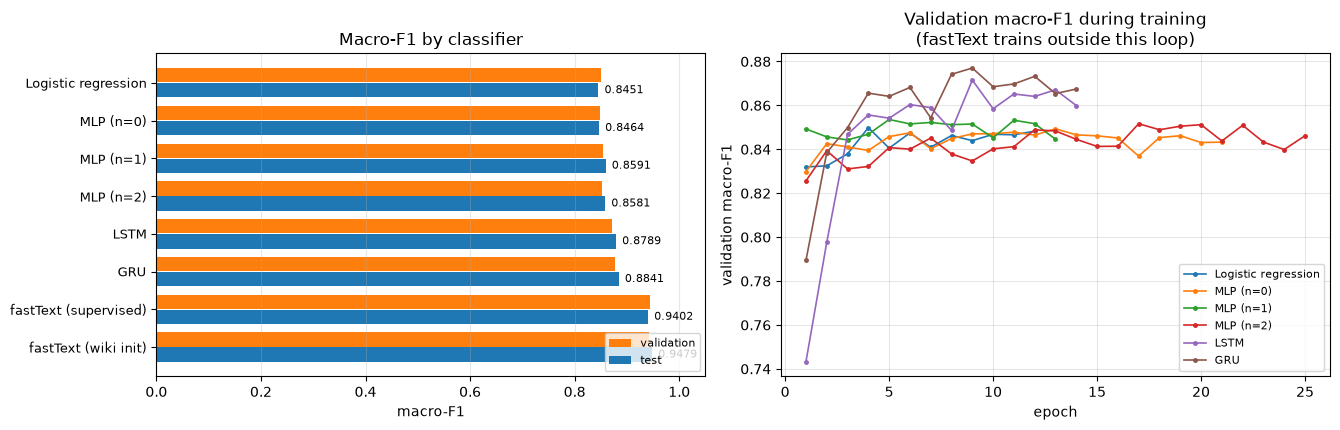

In [21]:
import matplotlib.pyplot as plt

names = [r["model"] for r in ROWS]
y = np.arange(len(ROWS))
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.4))

ax[0].barh(y - 0.2, [r["val_macro_f1"] for r in ROWS], height=0.38,
           color="tab:orange", label="validation")
ax[0].barh(y + 0.2, [r["test_macro_f1"] for r in ROWS], height=0.38,
           color="tab:blue", label="test")
ax[0].set_yticks(y)
ax[0].set_yticklabels(names, fontsize=9)
ax[0].invert_yaxis()
ax[0].set_xlim(0, 1.05)
ax[0].set_xlabel("macro-F1")
ax[0].set_title("Macro-F1 by classifier")
ax[0].legend(loc="lower right", fontsize=8)
ax[0].grid(axis="x", alpha=.3)
for i, r in enumerate(ROWS):
    ax[0].text(r["test_macro_f1"] + .012, i + 0.2, "%.4f" % r["test_macro_f1"],
               va="center", fontsize=8)

HISTORIES = [("Logistic regression", lr_model.history_),
             ("MLP (n=0)", MLP_MODELS[0].history_),
             ("MLP (n=1)", MLP_MODELS[1].history_),
             ("MLP (n=2)", MLP_MODELS[2].history_),
             ("LSTM", lstm.history_),
             ("GRU", gru.history_)]
for name, hist in HISTORIES:
    ax[1].plot([h["epoch"] for h in hist], [h["val_macro_f1"] for h in hist],
               marker="o", ms=2.5, lw=1.2, label=name)
ax[1].set_xlabel("epoch")
ax[1].set_ylabel("validation macro-F1")
ax[1].set_title("Validation macro-F1 during training\n(fastText trains outside this loop)")
ax[1].grid(alpha=.3)
ax[1].legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

In [22]:
# ----------------------- where the macro-F1 of each classifier is lost -------------------
PREDS = {
    "Logistic regression": lr_test_pred,
    "MLP (n=0)": MLP_MODELS[0].predict(A_test),
    "MLP (n=1)": MLP_MODELS[1].predict(A_test),
    "MLP (n=2)": MLP_MODELS[2].predict(A_test),
    "LSTM": lstm_test_pred,
    "GRU": gru_test_pred,
    "fastText (supervised)": ft_test_pred,
    "fastText (wiki init)": ft_pre_test_pred,
}

per_lang_f1 = {name: prf_per_class(y_test, pred, N_CLASSES)[2] for name, pred in PREDS.items()}

head = "%-6s%9s" % ("lang", "coverage") + "".join("%12s" % n[:11] for n in ORDER)
print(head)
print("-" * len(head))
for i, lang in enumerate(LABELS):
    print("%-6s%8.1f%%" % (lang, 100 * COVERAGE[lang])
          + "".join("%12.3f" % per_lang_f1[n][i] for n in ORDER))
print("-" * len(head))
print("%-6s%9s" % ("macro", "") + "".join("%12.3f" % per_lang_f1[n].mean() for n in ORDER))

lang   coverage Logistic re   MLP (n=0)   MLP (n=1)   MLP (n=2)        LSTM         GRU fastText (s fastText (w
---------------------------------------------------------------------------------------------------------------
as        80.2%       0.995       1.000       0.985       0.985       0.995       1.000       0.990       0.995
bd        34.0%       0.688       0.739       0.821       0.778       0.804       0.839       0.969       0.969
bn        82.4%       0.985       0.990       0.985       0.990       0.995       1.000       0.995       0.995
dg        57.4%       0.785       0.794       0.806       0.860       0.780       0.844       0.941       0.950
en        95.3%       0.685       0.688       0.701       0.697       0.765       0.667       0.680       0.720
gom       83.8%       0.673       0.652       0.734       0.740       0.702       0.670       0.713       0.754
gu        86.5%       1.000       1.000       1.000       1.000       1.000       1.000       1.000     

best classifier: fastText (wiki init)

language    prec  recall      f1  support
--------------------------------------
as     1.0000  0.9900  0.9950      100
bd     0.9896  0.9500  0.9694      100
bn     0.9901  1.0000  0.9950      100
dg     0.9412  0.9600  0.9505      100
en     0.7200  0.7200  0.7200      100
gom    0.7912  0.7200  0.7539      100
gu     1.0000  1.0000  1.0000      100
kha    0.6944  0.7500  0.7212      100
kn     0.9901  1.0000  0.9950      100
ks     0.9900  0.9900  0.9900      100
mai    0.9608  0.9800  0.9703      100
ml     1.0000  1.0000  1.0000      100
mni    1.0000  0.9800  0.9899      100
mr     0.8000  0.8000  0.8000      100
ne     0.9802  0.9900  0.9851      100
or     1.0000  1.0000  1.0000      100
pa     1.0000  1.0000  1.0000      100
sa     0.9612  0.9900  0.9754      100
sat    1.0000  1.0000  1.0000      100
sd     1.0000  1.0000  1.0000      100
ta     1.0000  0.9900  0.9950      100
te     1.0000  1.0000  1.0000      100
ur     1.0000  0.9900 

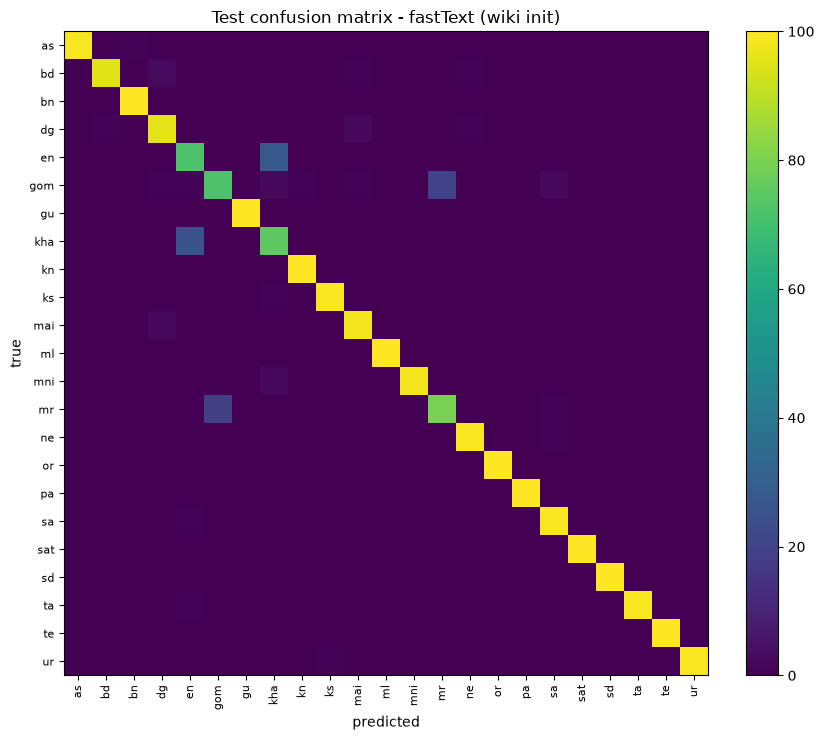

most frequent confusions (true -> predicted):
   28  en     -> kha
   25  kha    -> en
   20  gom    -> mr
   19  mr     -> gom
    3  bd     -> dg
    2  mni    -> kha
    2  mai    -> dg
    2  gom    -> sa
    2  gom    -> kha
    2  dg     -> mai
    1  ur     -> ks
    1  ta     -> en


In [23]:
# the classification report and confusion matrix of the best classifier
print("best classifier:", best["model"])
print()
print(classification_report(y_test, PREDS[best["model"]]))

cm = confusion_matrix(y_test, PREDS[best["model"]], N_CLASSES)
fig, ax = plt.subplots(figsize=(8.5, 7.5))
im = ax.imshow(cm, cmap="viridis")
ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(LABELS, rotation=90, fontsize=8)
ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(LABELS, fontsize=8)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("Test confusion matrix - %s" % best["model"])
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()

pairs = [(int(cm[i, j]), LABELS[i], LABELS[j])
         for i in range(N_CLASSES) for j in range(N_CLASSES) if i != j and cm[i, j]]
pairs.sort(reverse=True)
print("most frequent confusions (true -> predicted):")
for count, t, p in pairs[:12]:
    print("  %3d  %-6s -> %s" % (count, t, p))

In [24]:
# ---------------- ablation: how much does the missing vocabulary cost us? ---------------
# Not asked for by the assignment, but it makes the table above readable.  fastText publishes
# no wiki model for five of the 23 languages, and even for the others the 200k-word prefix we
# stream does not cover every inflected form.  Here every corpus word *without* a pretrained
# vector gets a fixed random unit vector instead of the zero vector - no extra linguistic
# information, only the ability to tell those words apart.  The gap between the two runs is
# the part of the score that is lost to coverage rather than to the classifier.
rng = np.random.RandomState(SEED)
missing = sorted(CORPUS_VOCAB - set(WORD2ID))
VOCAB_FULL = VOCAB + missing
WORD2ID_FULL = {w: i for i, w in enumerate(VOCAB_FULL)}
extra = rng.randn(len(missing), EMB_DIM).astype(np.float32)
extra /= np.linalg.norm(extra, axis=1, keepdims=True)
EMB_FULL = np.vstack([EMB, extra])
print("word types with a pretrained vector : {:,}".format(len(VOCAB) - 2))
print("word types given a random vector    : {:,}".format(len(missing)))

B_train = average_vectors(TOK_TRAIN, EMB_FULL, WORD2ID_FULL)
B_val = average_vectors(TOK_VAL, EMB_FULL, WORD2ID_FULL)
B_test = average_vectors(TOK_TEST, EMB_FULL, WORD2ID_FULL)
mu, sd = B_train.mean(axis=0), B_train.std(axis=0)
sd[sd == 0] = 1.0
B_train, B_val, B_test = (B_train - mu) / sd, (B_val - mu) / sd, (B_test - mu) / sd

ABLATION = []
for name, hidden in (("Logistic regression", ()), ("MLP (n=1)", (CONFIG["mlp_hidden"],))):
    m = MLP(B_train.shape[1], N_CLASSES, hidden=hidden, lr=CONFIG["lr"], l2=CONFIG["l2"],
            dropout=CONFIG["mlp_dropout"] if hidden else 0.0)
    m.fit(B_train, y_train, B_val, y_val, verbose=False)
    pretrained_only = next(r["test_macro_f1"] for r in ROWS if r["model"] == name)
    with_random = macro_f1(y_test, m.predict(B_test))
    ABLATION.append((name, pretrained_only, with_random))

print("\n%-22s%22s%22s%10s" % ("classifier", "pretrained only", "+ random for OOV", "delta"))
for name, a, b in ABLATION:
    print("%-22s%22.4f%22.4f%+10.4f" % (name, a, b, b - a))

word types with a pretrained vector : 69,795
word types given a random vector    : 50,541



classifier                   pretrained only      + random for OOV     delta
Logistic regression                   0.8451                0.8926   +0.0474
MLP (n=1)                             0.8591                0.8986   +0.0396
